# # Olist E-Commerce Data Analysis

## 📌 Project Overview
This project analyzes the Olist e-commerce dataset to understand order trends, delivery performance, and business insights.

## 📊 Objectives
- Analyze order status distribution
- Study yearly and monthly sales trends
- Evaluate delivery performance
- Identify delays and outliers

## 🛠️ Tools Used
- Python (Pandas, Matplotlib)
- Jupyter Notebook

## 🔍 Key Insights
- Majority of orders are successfully delivered (~96%)
- Orders increased significantly from 2017 to 2018
- Deliveries are on average 12 days earlier than expected
- Best delivery performance observed in June
- Slight delays observed during November (high demand period)

## 📁 Dataset
Olist E-commerce dataset from Kaggle

## 🚀 Conclusion
The analysis shows strong logistics performance with early deliveries, but seasonal variations impact efficiency.

# Loading all datasets

In [3]:
import os
os.listdir()

['-1.14-windows.xml',
 '.anaconda',
 '.android',
 '.cache',
 '.conda',
 '.condarc',
 '.continuum',
 '.dotnet',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jfreereport',
 '.jupyter',
 '.Ld9VirtualBox',
 '.matplotlib',
 '.ms-ad',
 '.templateengine',
 '.vscode',
 'anaconda_projects',
 'AppData',
 'Application Data',
 'Contacts',
 'Cookies',
 'data sci',
 'Documents',
 'Downloads',
 'Favorites',
 'kaggleOLIS',
 'Links',
 'Local Settings',
 'matplotlib_Assignmen.ipynb',
 'Microsoft',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{7486966e-e6ae-11ef-9892-ba0453f93d25}.TM.blf',
 'NTUSER.DAT{7486966e-e6ae-11ef-9892-ba0453f93d25}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{7486966e-e6ae-11ef-9892-ba0453f93d25}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OLIS.ipynb',
 'OneDrive',
 'PrintHood',
 'Recent',
 'Saved Games',
 'Searches',
 'SendTo',
 'Start Menu',
 'Templates',
 'Untitled.ipynb',
 'Vid

In [4]:
import os
os.getcwd()

'C:\\Users\\91886'

In [5]:
os.listdir("kaggleOLIS")

['category.csv',
 'Customers.csv',
 'DataFrame.csv',
 'geolocation.csv',
 'Orders.csv',
 'Order_items.csv',
 'payments.csv',
 'Products.csv',
 'reviews.csv',
 'sellers.csv']

In [1]:
import pandas as pd

Category = pd.read_csv("../data/category.csv")
customers = pd.read_csv("../data/Customers.csv")
geo = pd.read_csv("../data/geolocation.csv")
order_items = pd.read_csv("../data/Order_items.csv")
orders = pd.read_csv("../data/Orders.csv")
Payments = pd.read_csv("../data/payments.csv")
products = pd.read_csv("../data/Products.csv")
Reviews = pd.read_csv("../data/reviews.csv")
Sellers = pd.read_csv("../data/sellers.csv")

# Check size of the dataset

In [2]:
Category.shape
customers.shape
orders.shape

(99433, 12)

# Structure + health check Preview data Numerical summary

In [9]:
orders.info()
orders.head()
orders.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99433 entries, 0 to 99432
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99433 non-null  object
 1   customer_id                    99433 non-null  object
 2   order_status                   99433 non-null  object
 3   order_purchase_timestamp       99433 non-null  object
 4   order_approved_at              99433 non-null  object
 5   order_delivered_carrier_date   99433 non-null  object
 6   order_delivered_customer_date  99433 non-null  object
 7   order_estimated_delivery_date  99433 non-null  object
 8   delivery_days                  99433 non-null  int64 
 9   delivery_delay                 99433 non-null  int64 
 10  purchase_month                 99433 non-null  int64 
 11  purchase_year                  99433 non-null  int64 
dtypes: int64(4), object(8)
memory usage: 9.1+ MB


,delivery_days,delivery_delay,purchase_month,purchase_year
count,99433.000000,99433.000000,99433.000000,99433.000000
mean,12.104231,-11.901129,6.032152,2017.539821
std,9.432891,10.218684,3.233084,0.505009
min,0.000000,-147.000000,1.000000,2016.000000
25%,6.000000,-17.000000,3.000000,2017.000000
50%,10.000000,-12.000000,6.000000,2018.000000
75%,15.000000,-7.000000,8.000000,2018.000000
max,209.000000,188.000000,12.000000,2018.000000


# To change string into date, time timestamp

In [10]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [11]:
orders.info()
orders.head()
orders.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99433 entries, 0 to 99432
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99433 non-null  object        
 1   customer_id                    99433 non-null  object        
 2   order_status                   99433 non-null  object        
 3   order_purchase_timestamp       99433 non-null  datetime64[ns]
 4   order_approved_at              99433 non-null  datetime64[ns]
 5   order_delivered_carrier_date   99433 non-null  object        
 6   order_delivered_customer_date  99433 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99433 non-null  datetime64[ns]
 8   delivery_days                  99433 non-null  int64         
 9   delivery_delay                 99433 non-null  int64         
 10  purchase_month                 99433 non-null  int64         
 11  purchase_year  

,order_purchase_timestamp,order_approved_at,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay,purchase_month,purchase_year
count,99433,99433,99433,99433,99433.000000,99433.000000,99433.000000,99433.000000
mean,2017-12-31 08:31:34.338137088,2017-12-31 18:55:45.665030912,2018-01-12 21:58:08.064274432,2018-01-24 02:56:59.154606592,12.104231,-11.901129,6.032152,2017.539821
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-11 13:46:32,2016-09-30 00:00:00,0.000000,-147.000000,1.000000,2016.000000
25%,2017-09-12 14:40:50,2017-09-12 21:44:05,2017-09-22 20:04:03,2017-10-03 00:00:00,6.000000,-17.000000,3.000000,2017.000000
50%,2018-01-18 22:54:15,2018-01-19 11:36:13,2018-02-01 14:36:44,2018-02-15 00:00:00,10.000000,-12.000000,6.000000,2018.000000
75%,2018-05-04 15:26:03,2018-05-04 23:33:51,2018-05-15 16:35:22,2018-05-25 00:00:00,15.000000,-7.000000,8.000000,2018.000000
max,2018-10-17 17:30:18,2018-10-17 17:30:18,2018-10-29 17:30:18,2018-11-12 00:00:00,209.000000,188.000000,12.000000,2018.000000
std,NaN,NaN,NaN,NaN,9.432891,10.218684,3.233084,0.505009


In [12]:
orders['order_delivered_carrier_date'] = pd.to_datetime(
    orders['order_delivered_carrier_date']
)

DateParseError: Unknown datetime string format, unable to parse: <bound method NDFrame.fillna of 0       2017-10-04 19:55:00
1       2018-07-26 14:31:00
2       2018-08-08 13:50:00
3       2017-11-22 13:39:59
4       2018-02-14 19:46:34
                ...        
99436   2017-03-10 11:18:03
99437   2018-02-07 23:22:42
99438   2017-08-28 20:52:26
99439   2018-01-12 15:35:03
99440   2018-03-09 22:11:59
Name: order_delivered_carrier_date, Length: 99433, dtype: datetime64[ns]>, at position 0

In [13]:
orders['order_delivered_carrier_date'] = pd.to_datetime(
    orders['order_delivered_carrier_date'],
    errors='coerce'
)

In [14]:
orders.info()
orders.head()
orders.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99433 entries, 0 to 99432
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99433 non-null  object        
 1   customer_id                    99433 non-null  object        
 2   order_status                   99433 non-null  object        
 3   order_purchase_timestamp       99433 non-null  datetime64[ns]
 4   order_approved_at              99433 non-null  datetime64[ns]
 5   order_delivered_carrier_date   0 non-null      datetime64[ns]
 6   order_delivered_customer_date  99433 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99433 non-null  datetime64[ns]
 8   delivery_days                  99433 non-null  int64         
 9   delivery_delay                 99433 non-null  int64         
 10  purchase_month                 99433 non-null  int64         
 11  purchase_year  

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay,purchase_month,purchase_year
count,99433,99433,0,99433,99433,99433.000000,99433.000000,99433.000000,99433.000000
mean,2017-12-31 08:31:34.338137088,2017-12-31 18:55:45.665030912,NaT,2018-01-12 21:58:08.064274432,2018-01-24 02:56:59.154606592,12.104231,-11.901129,6.032152,2017.539821
min,2016-09-04 21:15:19,2016-09-15 12:16:38,NaT,2016-10-11 13:46:32,2016-09-30 00:00:00,0.000000,-147.000000,1.000000,2016.000000
25%,2017-09-12 14:40:50,2017-09-12 21:44:05,NaT,2017-09-22 20:04:03,2017-10-03 00:00:00,6.000000,-17.000000,3.000000,2017.000000
50%,2018-01-18 22:54:15,2018-01-19 11:36:13,NaT,2018-02-01 14:36:44,2018-02-15 00:00:00,10.000000,-12.000000,6.000000,2018.000000
75%,2018-05-04 15:26:03,2018-05-04 23:33:51,NaT,2018-05-15 16:35:22,2018-05-25 00:00:00,15.000000,-7.000000,8.000000,2018.000000
max,2018-10-17 17:30:18,2018-10-17 17:30:18,NaT,2018-10-29 17:30:18,2018-11-12 00:00:00,209.000000,188.000000,12.000000,2018.000000
std,NaN,NaN,NaN,NaN,NaN,9.432891,10.218684,3.233084,0.505009


In [15]:
orders.isnull().sum()

order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_approved_at                    0
order_delivered_carrier_date     99433
order_delivered_customer_date        0
order_estimated_delivery_date        0
delivery_days                        0
delivery_delay                       0
purchase_month                       0
purchase_year                        0
dtype: int64

# dropped the column "carrier date" bcz of all 100% null values

In [16]:
orders = orders.drop(columns=['order_delivered_carrier_date'])

# checked whether the column is successfully or not

In [17]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'delivery_days', 'delivery_delay',
       'purchase_month', 'purchase_year'],
      dtype='object')

# Counts how many orders fall into each category.

In [18]:
orders['order_status'].value_counts()

order_status
delivered      96470
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

# Counts orders per year

In [19]:
orders['purchase_year'].value_counts()

purchase_year
2018    54005
2017    45099
2016      329
Name: count, dtype: int64

# Counts orders per month arranges months Jan → Dec.. Insight:

# Peak months → May, July, August

 # Drop → September, October

In [20]:
orders['purchase_month'].value_counts().sort_index()

purchase_month
1      8069
2      8508
3      9893
4      9343
5     10572
6      9409
7     10315
8     10843
9      4305
10     4959
11     7543
12     5674
Name: count, dtype: int64

# Groups by order status and calculates average delay..
# INSIGHT Orders are delivered earlier than expected

In [21]:
orders.groupby('order_status')['delivery_delay'].mean()

order_status
approved      -10.500000
canceled      -10.680000
created       -15.800000
delivered     -11.875889
invoiced      -13.582803
processing    -17.727575
shipped       -13.239386
unavailable   -10.945813
Name: delivery_delay, dtype: float64

# On average, deliveries are ~12 days early

In [29]:
delivered_orders = orders[orders['order_status'] == 'delivered']

delivered_orders['delivery_delay'].mean()

np.float64(-11.875888877371203)

# to Detect outliers

In [30]:
delivered_orders['delivery_delay'].describe()

count    96470.000000
mean       -11.875889
std         10.182105
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay, dtype: float64

In [31]:
Q1 = delivered_orders['delivery_delay'].quantile(0.25)
Q3 = delivered_orders['delivery_delay'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

clean_orders = delivered_orders[
    (delivered_orders['delivery_delay'] >= lower_bound) &
    (delivered_orders['delivery_delay'] <= upper_bound)
]

In [32]:
clean_orders = delivered_orders[
    (delivered_orders['delivery_delay'] >= -30) &
    (delivered_orders['delivery_delay'] <= 30)
]

In [33]:

delivered_orders['delivery_delay'].describe()

count    96470.000000
mean       -11.875889
std         10.182105
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay, dtype: float64

# Shows most frequent delay values

In [24]:
delivered_orders['delivery_delay'].value_counts().head(10)

delivery_delay
-14    7126
-13    5963
-15    5345
-7     4837
-8     4828
-10    4646
-9     4626
-11    4619
-12    4556
-16    3903
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

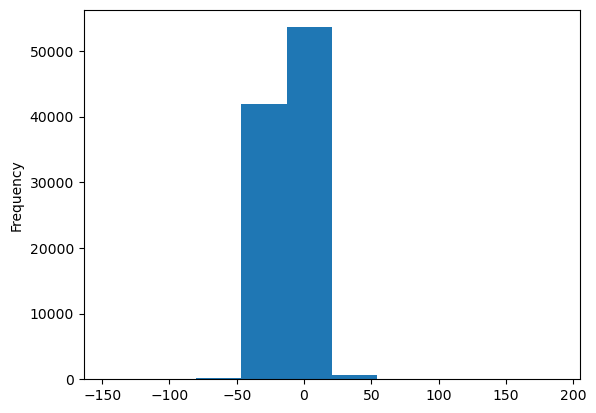

In [25]:
delivered_orders['delivery_delay'].plot(kind='hist')

In [26]:
clean_orders = delivered_orders[
    (delivered_orders['delivery_delay'] > -50) &
    (delivered_orders['delivery_delay'] < 50)
]

In [27]:
clean_orders['delivery_delay'].describe()

count    96226.000000
mean       -11.940224
std          9.278208
min        -49.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max         49.000000
Name: delivery_delay, dtype: float64

# Visualized delivery delay distribution to identify skewness and extreme outliers before cleaning

# Applied business-rule-based filtering to remove unrealistic delivery delays beyond ±50 days

# Analyzed monthly delivery performance to identify seasonal variations in logistics efficiency

# To find which months have delays or faster deliveries

In [28]:
clean_orders.groupby('purchase_month')['delivery_delay'].mean()

purchase_month
1    -14.371337
2    -10.628473
3     -8.244907
4    -13.061070
5    -12.672832
6    -17.063070
7    -11.861419
8    -10.095338
9    -11.360937
10   -13.026539
11    -8.290252
12   -13.054516
Name: delivery_delay, dtype: float64

# Order Status Distribution.. 
# Most orders are successfully delivered (~96%), indicating strong operational efficiency with minimal cancellations.

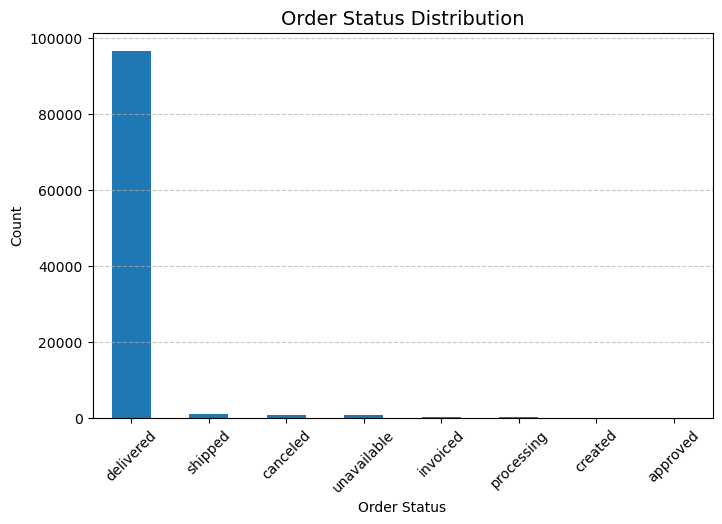

In [6]:
orders['order_status'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)
plt.title("Order Status Distribution", fontsize=14)
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Orders per Year.. 
# There is a clear growth trend from 2017 to 2018, suggesting business expansion.

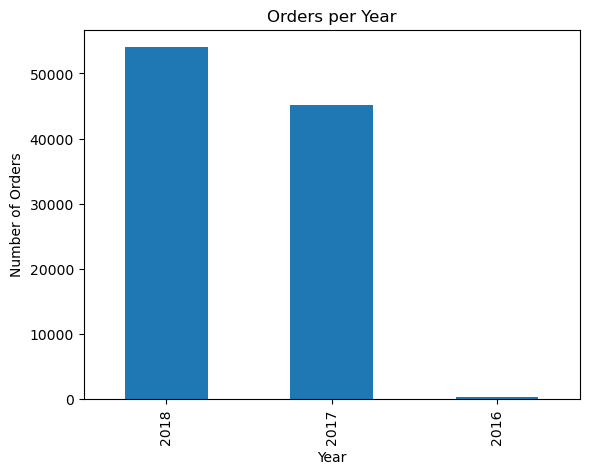

In [4]:
orders['purchase_year'].value_counts().plot(kind='bar')
plt.title("Orders per Year")
plt.xlabel("Year")
plt.ylabel("Number of Orders")
plt.show()

# Orders per Month.. 
# Orders peak between May and August, while a sharp decline is observed in September, possibly due to seasonal factors.

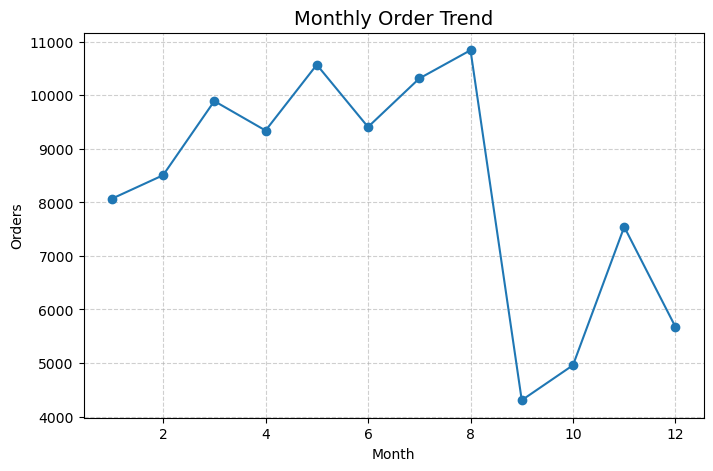

In [7]:
orders['purchase_month'].value_counts().sort_index().plot(
    kind='line',
    marker='o',
    figsize=(8,5)
)
plt.title("Monthly Order Trend", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Orders")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()